In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [2]:
!pip install keras-tuner~=1.4.7
!pip install tensorflow~=2.12.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
#%cd /content/drive/MyDrive/HandSignDetectionProject/
#!ls

/content/drive/MyDrive/HandSignDetectionProject
classifier.py  cnn_train_prueba.py  Data  Data_kaggle  logs  Model  Untitled


In [3]:
########################
# COPIAMOS DATA A LOCAL
########################

!cp -r /content/drive/MyDrive/HandSignDetectionProject/Data /content/Data

########################
# AHORA USAMOS /content/Data EN VEZ DE /content/drive
########################

In [4]:
import os
import random
import shutil
import sys

def copy_and_shuffle_images(src_dir, dst_dir):
    """
    Copia todas las imágenes desde src_dir hasta dst_dir,
    manteniendo la estructura de subcarpetas, pero en un orden aleatorio.
    Cada imagen se renombra a shuffled_XXXXX con su extensión original.
    """
    # Verificar que src_dir existe
    if not os.path.isdir(src_dir):
        print(f"Error: El directorio de origen '{src_dir}' no existe o no es una carpeta.")
        sys.exit(1)

    # Si dst_dir existe, lo borramos entero
    if os.path.exists(dst_dir):
        print(f"Borrando carpeta existente: {dst_dir}")
        shutil.rmtree(dst_dir)

    # Crear la carpeta de destino vacía
    os.makedirs(dst_dir, exist_ok=True)

    # Listar subcarpetas (clases) en src_dir
    classes = sorted(os.listdir(src_dir))

    for cls_name in classes:
        cls_folder_src = os.path.join(src_dir, cls_name)

        # Omitir si no es una carpeta
        if not os.path.isdir(cls_folder_src):
            continue

        # Crear la carpeta de destino para esa clase
        cls_folder_dst = os.path.join(dst_dir, cls_name)
        os.makedirs(cls_folder_dst, exist_ok=True)

        # Listar imágenes en la carpeta origen
        all_files = os.listdir(cls_folder_src)

        # Filtrar solo extensiones de imagen
        valid_ext = (".jpg", ".jpeg", ".png")
        image_files = [f for f in all_files
                       if f.lower().endswith(valid_ext)]

        # Barajar la lista de ficheros
        random.shuffle(image_files)

        print(f"Clase '{cls_name}': Encontradas {len(image_files)} imágenes. Copiando y barajando...")

        # Copiar cada imagen con un nombre nuevo shuffled_XXXXX.ext
        for i, fname in enumerate(image_files):
            src_path = os.path.join(cls_folder_src, fname)

            # Extraer extensión
            _, ext = os.path.splitext(fname)
            ext = ext.lower()  # normalizar

            # Construir nuevo nombre
            new_fname = f"shuffled_{i:05d}{ext}"
            dst_path = os.path.join(cls_folder_dst, new_fname)

            shutil.copy2(src_path, dst_path)  # copy2 para preservar metadata si se quiere

    print("\n¡Proceso completado!")
    print(f"Se ha creado '{dst_dir}' con las mismas subcarpetas que '{src_dir}', pero con imágenes barajadas.")


if __name__ == "__main__":
    src_directory = "/content/Data"  # Tu carpeta original
    dst_directory = "/content/Data_disordered"  # Nueva carpeta con imágenes desordenadas

    copy_and_shuffle_images(src_directory, dst_directory)


Clase 'A': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'B': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'C': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'D': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'E': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'F': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'G': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'H': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'I': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'J': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'K': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'L': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'M': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'N': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'O': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'P': Encontradas 1000 imágenes. Copiando y barajando...
Clase 'Q

In [5]:

import json
import os

import cv2
import keras_tuner as kt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    BatchNormalization, GlobalAveragePooling2D,
    Conv2D, MaxPooling2D, Dense, Dropout
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Constantes ---
IMG_SIZE = 224
EPOCHS = 70
DATA_DIR = "/content/Data_disordered"
MODEL_PATH = "/content/drive/MyDrive/HandSignDetectionProject/Model/RS/my_cnn_model_tuned.h5"
HPARAMS_JSON_PATH = "/content/drive/MyDrive/HandSignDetectionProject/Model/RS/best_hparams.json"
HPARAMS_HTML_PATH = "/content/drive/MyDrive/HandSignDetectionProject/Model/RS/best_hparams.html"


def load_dataset(data_dir=DATA_DIR, img_size=IMG_SIZE):
    """
    Carga las imágenes del directorio 'Data' donde cada subcarpeta es una clase (A, B, C, etc.)
    Devuelve arrays de numpy para X (imágenes) e y (etiquetas).
    """
    labels = []
    images = []

    # Lista de carpetas (clases)
    classes = sorted(os.listdir(data_dir))
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

    for cls_name in classes:
        cls_folder = os.path.join(data_dir, cls_name)
        if not os.path.isdir(cls_folder):
            continue

        for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            img = np.array(img, dtype=np.float32)
            img = img / 255.0

            images.append(img)
            labels.append(class_to_idx[cls_name])

    images = np.array(images)
    labels = np.array(labels)
    return images, labels, classes


def build_model(hp, input_shape=(224, 224, 3), num_classes=26):
    model = Sequential()

    # Hiperparámetros para la activación #

    dropout_rate = hp.Float('dropout_rate', min_value=0.0, max_value=0.7, step=0.1)
    lr = hp.Choice('learning_rate', values=[0.0001, 0.001])
    ks = hp.Choice('kernel_size', values=[3, 5])

    # Capa convolucional 1
    model.add(Conv2D(filters=32, kernel_size=(ks, ks), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Capa convolucional 2
    model.add(Conv2D(filters=64, kernel_size=(ks, ks), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Capa convolucional 3
    model.add(Conv2D(filters=128, kernel_size=(ks, ks), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Capa convolucional 4
    model.add(Conv2D(filters=256, kernel_size=(ks, ks), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Global Average Pooling
    model.add(GlobalAveragePooling2D())

    # Capa densa intermedia
    model.add(Dense(512, activation='relu'))

    # Dropout
    model.add(Dropout(dropout_rate))

    # Capa de salida
    model.add(Dense(num_classes, activation='softmax'))

    # Learning rate


    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def main():
    # 1. Generadores de datos con validación (20%)
    datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2
    )

    train_generator = datagen.flow_from_directory(
        DATA_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=32, #Aumentar dependiendo de la GPU usada
        class_mode='sparse',
        subset='training'
    )

    validation_generator = datagen.flow_from_directory(
        DATA_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=32,
        class_mode='sparse',
        subset='validation'
    )

    num_classes = len(train_generator.class_indices)
    print("Clases encontradas:", train_generator.class_indices)

    # 1.5. verificamos si esta utilizando la gpu
    print("Dispositivos GPU disponibles:", tf.config.list_physical_devices('GPU'))

    # 2. Definimos RandomSearch
    tuner = kt.RandomSearch(
        hypermodel=lambda hp: build_model(
            hp,
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            num_classes=num_classes
        ),
        objective='val_accuracy',
        max_trials=2,
        executions_per_trial=1,
        overwrite=True,
        directory='Model/RS/tuner_dir',
        project_name='my_cnn_randomSearch'
    )

    # 3. Lanzamos la búsqueda de hiperparámetros
    tuner.search(
        train_generator,
        epochs=EPOCHS,
        validation_data=validation_generator,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5)]
    )

    # 4. Obtenemos los mejores hiperparámetros
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print("Mejores hiperparámetros encontrados:")
    for param, value in best_hp.values.items():
        print(f"  {param}: {value}")

    # Guardar hiperparámetros en JSON
    os.makedirs(os.path.dirname(HPARAMS_JSON_PATH), exist_ok=True)
    with open(HPARAMS_JSON_PATH, "w") as f:
        json.dump(best_hp.values, f, indent=4)
    print(f"Hiperparámetros guardados en: {HPARAMS_JSON_PATH}\n")

    # Guardar en HTML
    html_str = """
    <html>
    <head><meta charset="UTF-8"><title>Mejores Hiperparámetros</title></head>
    <body>
      <h2>Mejores Hiperparámetros Encontrados</h2>
      <table border="1">
        <tr><th>Hiperparámetro</th><th>Valor</th></tr>
    """

    for param, value in best_hp.values.items():
        html_str += f"<tr><td>{param}</td><td>{value}</td></tr>"

    html_str += """
      </table>
    </body>
    </html>
    """

    with open(HPARAMS_HTML_PATH, "w") as f:
        f.write(html_str)

    print(f"Hiperparámetros guardados en HTML: {HPARAMS_HTML_PATH}\n")

    # 5. Construimos y entrenamos el modelo con mejores hiperparámetros
    best_model = tuner.hypermodel.build(best_hp)
    best_model.summary()

    history = best_model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=validation_generator,
        verbose=1
    )

    # 6. Guardar el mejor modelo
    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    best_model.save(MODEL_PATH)
    print(f"Modelo guardado en: {MODEL_PATH}")

    # 7. Evaluar
    val_loss, val_acc = best_model.evaluate(validation_generator, verbose=0)
    print(f"Precisión en validación: {val_acc * 100:.2f}%, Pérdida: {val_loss:.4f}")

    # 8. Guardar mapeo de clases
    with open("/content/drive/MyDrive/HandSignDetectionProject/Model/RS/class_labels.txt", "w") as f:
        for cls_name in sorted(train_generator.class_indices, key=train_generator.class_indices.get):
            f.write(f"{cls_name}\n")
    print("Se ha guardado class_labels.txt con las clases.")

if __name__ == "__main__":
    main()


Trial 2 Complete [00h 19m 10s]
val_accuracy: 0.9992307424545288

Best val_accuracy So Far: 0.9992307424545288
Total elapsed time: 00h 29m 37s
Mejores hiperparámetros encontrados:
  dropout_rate: 0.4
  learning_rate: 0.0001
  kernel_size: 3
Hiperparámetros guardados en: /content/drive/MyDrive/HandSignDetectionProject/Model/RS/best_hparams.json

Hiperparámetros guardados en HTML: /content/drive/MyDrive/HandSignDetectionProject/Model/RS/best_hparams.html



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,258 (2.04 MB)

 Trainable params: 534,298 (2.04 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/70
650/650 ━━━━━━━━━━━━━━━━━━━━ 62s 83ms/step - accuracy: 0.4618 - loss: 1.8930 - val_accuracy: 0.6521 - val_loss: 1.0481
Epoch 2/70
650/650 ━━━━━━━━━━━━━━━━━━━━ 51s 78ms/step - accuracy: 0.8772 - loss: 0.4718 - val_accuracy: 0.9548 - val_loss: 0.2188
Epoch 3/70
650/650 ━━━━━━━━━━━━━━━━━━━━ 84s 81ms/step - accuracy: 0.9598 - loss: 0.1919 - val_accuracy: 0.9773 - val_loss: 0.1451
Epoch 4/70
650/650 ━━━━━━━━━━━━━━━━━━━━ 51s 78ms/step - accuracy: 0.9856 - loss: 0.0995 - val_accuracy: 0.9258 - val_loss: 0.2634
Epoch 5/70
650/650 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.9930 - loss: 0.0525 - val_accuracy: 0.9938 - val_loss: 0.0450
Epoch 6/70
650/650 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.9948 - loss: 0.0349 - val_accuracy: 0.9977 - val_loss: 0.0262
Epoch 7/70
650/650 ━━━━━━━━━━━━━━━━━━━━ 54s 82ms/step - accuracy: 0.9975 - loss: 0.0212 - val_accuracy: 0.9927 - val_loss: 0.0339
Epoch 8/70
650/650 ━━━━━━━━━━━━━━━━━━━━ 52s 80ms/step - accuracy: 0.9982 - loss: 0.0164 - 

Modelo guardado en: /content/drive/MyDrive/HandSignDetectionProject/Model/RS/my_cnn_model_tuned.h5
Precisión en validación: 99.81%, Pérdida: 0.0149
Se ha guardado class_labels.txt con las clases.


NameError: name 'history' is not defined

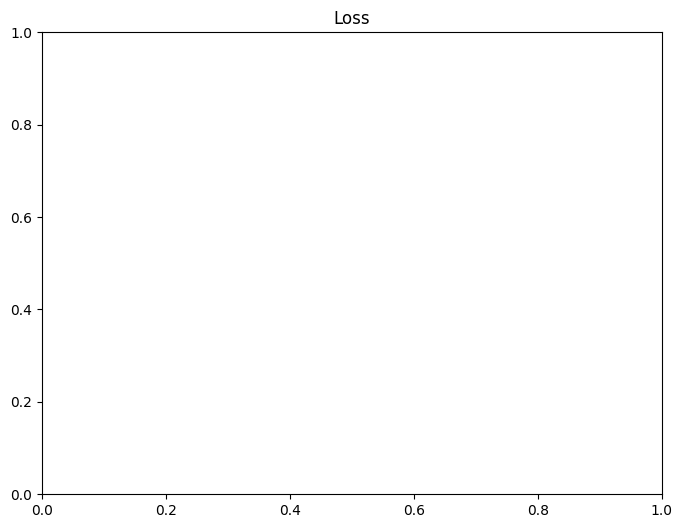

In [ ]:
import matplotlib.pyplot as plt

# Suponiendo que la variable 'history' está en el scope actual,
# si no, deberás guardarla en un objeto global o return en tu main().

# Gráfico de la función de pérdida
plt.figure(figsize=(8, 6))
plt.title("Loss")
plt.plot(history.epoch, history.history["loss"], label="Training Loss")
plt.plot(history.epoch, history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de la exactitud
plt.figure(figsize=(8, 6))
plt.title("Accuracy")
plt.plot(history.epoch, history.history["accuracy"], label="Training Accuracy")
plt.plot(history.epoch, history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
